In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from scipy.stats import shapiro, kstest, normaltest
from scipy.stats import levene
from scipy.stats import ttest_ind, mannwhitneyu
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

### 0 ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ

In [2]:
billing_premier = pd.read_csv('downloads/billing_premier_masked.csv', low_memory=False)
billing_rutube = pd.read_csv('downloads/billing_rutube_masked.csv', low_memory=False)
views_premier = pd.read_csv('downloads/premier_views.csv', low_memory=False)
views_rutube = pd.read_csv('downloads/rutube_views.csv', low_memory=False)

In [3]:
billing_premier.head()

,passport_id,subscription_id,user_id,reg_date,start_ts,end_ts,start_date,end_date,kind,money,sub_type,product_id,product_code,tariff_id_num,tariff_id,shop,vendor_code,payment_system,promo_campaign,is_multi,is_recovered,is_grace_period,auto_renewal,frozen,is_main,payment_type,card_type,card_expiry_month,card_expiry_year,card_last4,issuer_name,rrn,transaction_id,created_at,new,renewal,returned,inserted,inflow,outflow,sub_status,returned30,inflow30,outflow30,sub_status30,is_last,is_active,lt_total,lt_continouos,ltv,ltv_cycle,outflow_period,cnt_outflow,cnt_total_subs,cnt_sub,cnt_trial,cnt_sub_discount,cnt_promo,cnt_b2b_retail,cnt_external,shifted_end_date,next_start_date,next_kind,diff_day,first_start_date,first_sub_kind_since_reg,first_sub_kind_in_seq,next_start_date_by_product,sub_cycle_num,sub_cycle_start_date,cnt_trans_in_sub_cycle,same_seq_or_not,sub_cycle_num_by_product,num_sub_in_seq_by_product,week,month,year,version,rn,masked_phone
0,GQaLHYVMTW-NuTe34BRn0Q,28439387.0,33955973.0,2025-07-25,2025-08-17 21:16:38.064,2025-08-19 21:16:38.064,2025-08-17,2025-08-19,promo,0,NaN,5,START,0.0,NaN,unknown,PREMIER,NaN,pm_dr_start_trial,1,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-17 21:16:38.066,0,0,0,1,0,0,inserted,0,0,0,inserted,0,0,32.0,32.0,1,1,0.0,1,2,1,1,0,1,0,0,2025-08-24,2025-07-25,NaN,-7.0,2025-07-25,trial,NaN,NaN,1,2025-07-25,2,1,1,1,33,8,2025,2026-03-20 01:44:22.494,1,NaN
1,pHRTA0GoRdepAhyRxrXUhw,28233286.0,34030636.0,2025-07-27,2025-08-12 16:22:19.520,2026-01-08 16:22:19.520,2025-08-12,2026-01-08,promo,0,NaN,1,PREMIER,0.0,NaN,unknown,PREMIER,NaN,support_365,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-12 16:22:19.523,0,0,1,0,1,1,returned,1,0,0,returned30,0,0,163.0,149.0,0,0,1.0,2,2,1,0,0,2,0,0,2025-08-11,2026-01-09,sub,1.0,2025-07-28,promo,promo,2026-01-09,2,2025-08-12,1,1,2,1,33,8,2025,2026-03-20 01:44:22.494,2,NaN
2,PyVXmP79QkSiwHhkioLK0Q,27512714.0,34128289.0,2025-07-30,2025-07-30 12:55:28.379,2025-08-13 12:55:28.379,2025-07-30,2025-08-13,promo,0,NaN,1,PREMIER,0.0,NaN,test_shop,PREMIER,NaN,test-promo-all,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-30 12:55:28.382,1,0,0,0,1,1,new,0,1,1,new,1,0,14.0,14.0,0,0,NaN,1,1,0,0,0,1,0,0,NaN,NaN,NaN,NaN,2025-07-30,promo,promo,NaN,1,2025-07-30,1,1,1,1,31,7,2025,2026-03-20 01:44:22.494,3,NaN
3,Tvnn8fkzQ2OYSGxaViSfyg,28376458.0,34012152.0,2025-07-27,2025-08-16 11:05:20.036,2025-08-18 11:05:20.036,2025-08-16,2025-08-18,promo,0,NaN,5,START,0.0,NaN,unknown,PREMIER,NaN,pm_dr_start_trial,1,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-16 11:05:20.038,0,0,0,1,0,0,inserted,0,0,0,inserted,0,0,37.0,37.0,1,1,0.0,1,2,6,1,0,1,0,0,2025-08-31,2025-07-27,NaN,-15.0,2025-07-27,trial,NaN,NaN,1,2025-07-27,2,1,1,1,33,8,2025,2026-03-20 01:44:22.494,4,NaN
4,xsoSDnrgT-SZQkkrdN-aFg,30030227.0,33752356.0,2025-07-20,2025-09-30 22:08:47.577,2025-10-14 22:08:47.577,2025-09-30,2025-10-14,promo,0,NaN,1,PREMIER,0.0,NaN,unknown,PREMIER,NaN,support_365,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-30 22:08:47.578,0,0,1,0,1,1,returned,1,0,1,returned30,1,0,75.0,14.0,100,0,NaN,2,3,1,1,0,1,0,0,2025-09-19,NaN,NaN,11.0,2025-07-20,trial,promo,NaN,2,2025-09-30,1,1,2,1,40,9,2025,2026-03-20 01:44:22.494,5,NaN


In [4]:
billing_rutube.head()

,passport_id,subscription_id,user_id,reg_date,start_ts,end_ts,start_date,end_date,kind,money,sub_type,product_id,product_code,tariff_id_num,tariff_id,shop,vendor_code,payment_system,promo_campaign,is_multi,is_recovered,is_grace_period,auto_renewal,frozen,is_main,payment_type,card_type,card_expiry_month,card_expiry_year,card_last4,issuer_name,rrn,transaction_id,created_at,new,renewal,returned,inserted,inflow,outflow,sub_status,returned30,inflow30,outflow30,sub_status30,is_last,is_active,lt_total,lt_continouos,ltv,ltv_cycle,outflow_period,cnt_outflow,cnt_total_subs,cnt_sub,cnt_trial,cnt_sub_discount,cnt_promo,cnt_b2b_retail,cnt_external,shifted_end_date,next_start_date,next_kind,diff_day,first_start_date,first_sub_kind_since_reg,first_sub_kind_in_seq,next_start_date_by_product,sub_cycle_num,sub_cycle_start_date,cnt_trans_in_sub_cycle,same_seq_or_not,sub_cycle_num_by_product,num_sub_in_seq_by_product,week,month,year,version,masked_phone
0,70001203.0,29767246,4093737,2022-10-01,2025-11-23 22:01:54.480,2025-12-23 22:01:54.480,2025-11-23,2025-12-23,sub,99,RECURRENT,8,RUTUBE,2422,1000000234_sa_rutube_no_trial_99,WEB_Rutube,RUTUBE,NaN,NaN,0,0,1,1,0,1,sberbank,MasterCard,12.0,2025.0,1606.0,NaN,532733057354,30b56de2-000f-5001-8000-113f7264045b,2025-11-23 22:01:54.480,0,1,0,0,0,0,renewal,0,0,0,renewal,0,0,91.0,91.0,297,297,0.0,0,3,6,0,0,0,0,0,2025-11-23,2025-12-23,sub,0.0,2025-09-23,sub,sub,2025-12-23,1,2025-09-23,3,0,1,3,47,11,2025,2026-03-20 01:44:22.494,NaN
1,70005281.0,29770811,36264389,2025-09-23,2025-11-23 23:32:38.396,2025-12-23 23:32:38.396,2025-11-23,2025-12-23,sub,399,RECURRENT,2,PREMIER_RUTUBE_YAPPY,550,1000000240_PRY_30d_trial_edinaya_2024_399,WEB_Rutube,RUTUBE,NaN,NaN,0,0,1,1,0,1,sbp,NaN,NaN,NaN,NaN,NaN,B5327203239467060000110011640502,30b58326-000f-5001-9000-18b7603649c0,2025-11-23 23:32:38.396,0,1,0,0,0,0,renewal,0,0,0,renewal,0,0,91.0,91.0,799,799,0.0,0,3,5,1,0,0,0,0,2025-11-23,2025-12-23,sub,0.0,2025-09-23,trial,trial,2025-12-23,1,2025-09-23,3,0,1,3,47,11,2025,2026-03-20 01:44:22.494,NaN
2,70006181.0,29771719,8220298,2020-06-18,2025-11-24 00:22:48.717,2025-12-24 00:22:48.717,2025-11-24,2025-12-24,sub,99,RECURRENT,8,RUTUBE,2422,1000000234_sa_rutube_no_trial_99,WEB_Rutube,RUTUBE,NaN,NaN,0,0,1,1,0,1,bank_card,Visa,7.0,2029.0,8899.0,SBERBANK of Russia,532790984573,30b58ee8-000f-5000-8000-19be2ca73b51,2025-11-24 00:22:48.717,0,1,0,0,0,0,renewal,0,0,0,renewal,0,0,91.0,61.0,297,198,0.0,1,3,6,0,0,0,0,0,2025-11-24,2025-12-23,sub,0.0,2025-09-23,sub,sub,2025-12-23,2,2025-10-24,2,0,2,2,48,11,2025,2026-03-20 01:44:22.494,1d7bfbf1e7bc
3,70011487.0,29778420,36270577,NaN,2025-11-24 08:45:40.087,2025-12-24 08:45:40.087,2025-11-24,2025-12-24,sub,99,RECURRENT,8,RUTUBE,2422,1000000234_sa_rutube_no_trial_99,WEB_Rutube,RUTUBE,NaN,NaN,0,0,1,1,0,1,sbp,NaN,NaN,NaN,NaN,NaN,B5328054540989190000170011640502,30b604c4-000f-5001-8000-1f3049cab53e,2025-11-24 08:45:40.087,0,1,0,0,0,0,renewal,0,0,0,renewal,0,0,91.0,91.0,297,297,0.0,0,3,6,0,0,0,0,0,2025-11-24,2025-12-24,sub,0.0,2025-09-24,sub,sub,2025-12-24,1,2025-09-24,3,0,1,3,48,11,2025,2026-03-20 01:44:22.494,aa45175be4df
4,70014035.0,30900432,36272995,NaN,2025-11-22 13:18:10.923,2025-12-22 13:18:10.923,2025-11-22,2025-12-22,sub,99,RECURRENT,8,RUTUBE,2422,1000000234_sa_rutube_no_trial_99,WEB_Rutube,RUTUBE,NaN,NaN,0,0,1,1,0,1,bank_card,Mir,2.0,2035.0,8734.0,Tinkoff Bank,532608845208,30b3a1a2-000f-5001-9000-1292a08e3f62,2025-11-22 13:18:10.923,0,1,0,0,0,0,renewal,0,0,0,renewal,0,0,61.0,61.0,198,198,0.0,0,2,5,0,0,0,0,0,2025-11-22,2025-12-22,sub,0.0,2025-10-22,sub,sub,2025-12-22,1,2025-10-22,2,0,1,2,47,11,2025,2026-03-20 01:44:22.494,NaN


In [5]:
views_premier.head()

,cvid,user_id,cid,session_id,content_id,correct_view_date_msk,correct_start_datetime_msk,user_time_zone,content_duration,touch_point,device_type,operating_system,browser,is_embed,is_shorts,player_autoplay,country,city,district,content_type,profile_id,tvshow_id,rightsholder_id,product_name,last_traffic_source,utm_source,utm_medium,page_url,has_first_heartbeat,watchtime_total,custom_watchtime_total,true_view_time_total,view_depth_total,true_view_25_proc_total,true_view_50_proc_total,true_view_75_proc_total,true_view_100_proc_total,player_load_cnt,src
0,524832312189162891,NaN,86150a73-ce2e-42d5-a3e4-5d931e90e723,NaN,e22ac03fd982f961b0b39325861133fb,2025-08-21,2025-08-21 20:23:02.000,3.0,0,web,mobile,android,Chrome,0,0,0,Russia,St Petersburg,NaN,Прямой эфир,NaN,10465,7,PREMIER,NaN,NaN,NaN,https://yandex.ru/,1,0,0,0,NaN,NaN,NaN,NaN,NaN,0,trex
1,15364041374268417951,JDzBu19xbMA3HmHnNcCmTB,46d04545-e3eb-48cf-9ac3-53b979064977,7866834751744522462_1755757718451,58b8d2d5aece3a460d5c050908d45cbb,2025-08-21,2025-08-21 09:38:54.000,3.0,72,web,mobile,ios,Mobile Safari,0,0,0,Russia,Moscow,NaN,Прямой эфир,NaN,242212,323,PREMIER,direct,NaN,NaN,https://premier.one,1,120,120,72,1.0,1.0,1.0,1.0,1.0,0,trex
2,9149541940393802643,NaN,e1c09d79-2dfd-4d55-aa31-c41f402681ab,NaN,e22ac03fd982f961b0b39325861133fb,2025-08-21,2025-08-21 12:51:44.000,3.0,0,web,mobile,android,Chrome,0,0,0,Russia,Yaroslavl,NaN,Прямой эфир,NaN,10465,7,PREMIER,NaN,NaN,NaN,https://yandex.ru/,1,269,269,269,NaN,NaN,NaN,NaN,NaN,0,trex
3,11265540556168560352,NaN,7a3c20c9-af66-4e61-9dd0-f6ef9e863bb5,NaN,9293ea024fb4274cd96e8dee5a63974d,2025-08-21,2025-08-21 23:56:58.000,3.0,30,web,mobile,android,Chrome,0,0,0,Russia,Moscow,NaN,Прямой эфир,NaN,21907,319,PREMIER,NaN,NaN,NaN,https://yandex.ru/,1,180,180,30,1.0,1.0,1.0,1.0,1.0,0,trex
4,9208260673992747562,NaN,cdf816bd-2520-4d0a-8eeb-2bb61e8160be,NaN,e22ac03fd982f961b0b39325861133fb,2025-07-02,2025-07-02 19:53:23.000,3.0,0,web,mobile,android,Yandex Browser,0,0,0,Russia,Moscow,NaN,Прямой эфир,NaN,10465,7,PREMIER,NaN,NaN,NaN,https://premier.one,1,688,688,688,NaN,NaN,NaN,NaN,NaN,0,trex


In [6]:
views_rutube.head()

,cvid,user_id,cid,session_id,content_id,correct_view_date_msk,correct_start_datetime_msk,user_time_zone,content_duration,touch_point,device_type,operating_system,browser,is_embed,is_shorts,player_autoplay,country,city,district,content_type,channel_id,tvshow_id,rightsholder_id,product_name,last_traffic_source,utm_source,utm_medium,embed_location,has_first_heartbeat,watchtime_total,custom_watchtime_total,true_view_time_total,view_depth_total,true_view_25_proc_total,true_view_50_proc_total,true_view_75_proc_total,true_view_100_proc_total,player_load_cnt,goya_version
0,11188954951734178709_1750847513452_0,NaN,11188954951734178709,11188954951734178709_1750832732540,546602986e6a424d74d594876ddb3f04,2025-06-25,2025-06-25 13:31:55.000,3.0,0,web,tablet,android,chrome mobile webview,0,0,1.0,NaN,Donetsk,NaN,rst,23463954,2852,40,RUTUBE,organic,NaN,NaN,NaN,1,1151,1186.0,1186,0.0000,0,0,0,0,1,goya_v2
1,26368361151702619562_1750928805378_0,NaN,26368361151702619562,26368361151702619562_1750926679584,c37cd74192c6bc3d6cd6077c0c4fd686,2025-06-26,2025-06-26 12:06:47.000,3.0,0,web,tablet,android,yandexsearch,0,0,1.0,Russia,NaN,NaN,rst,23178409,0,10091,RUTUBE,direct,NaN,NaN,NaN,1,674,400.0,400,0.0000,0,0,0,0,1,goya_v2
2,4497360f1f1b5a4d17d44a645007a103,NaN,14887218726397337463,0c0c5d1c317b4bd38c2594d9e20fc3b6,9cd7f63167cbeab9b05136fc72635b4c,2025-06-21,2025-06-21 13:22:17.000,NaN,1144,app,mobile,android,NaN,0,0,NaN,Russia,Nizhny Novgorod,Volga Federal District,rtba,23976873,0,0,RUTUBE,ad,NaN,NaN,NaN,1,5,5.0,5,0.0044,0,0,0,0,1,goya_v1
3,57622725031735914533_1751018005014_0,NaN,57622725031735914533,57622725031735914533_1751017584587,546602986e6a424d74d594876ddb3f04,2025-06-27,2025-06-27 12:53:25.000,3.0,0,web,tablet,android,yandex browser,0,0,1.0,Russia,Kaluga,Central Federal District,rst,23463954,2852,40,RUTUBE,organic,NaN,NaN,NaN,1,6951,6967.0,6967,0.0000,0,0,0,0,1,goya_v2
4,19977753091745959292_1751209282790_0,NaN,19977753091745959292,19977753091745959292_1751207837435,c37cd74192c6bc3d6cd6077c0c4fd686,2025-06-29,2025-06-29 18:01:24.000,3.0,0,web,tablet,android,chrome mobile webview,0,0,1.0,Finland,Helsinki,NaN,rst,23178409,0,10091,RUTUBE,organic,NaN,NaN,NaN,1,8437,8779.0,8779,0.0000,0,0,0,0,1,goya_v2


### 1 ПЕРВИЧНЫЙ EDA (РАЗВЕДОЧНЫЙ АНАЛИЗ)

In [7]:
# Быстрый EDA
def light_eda(df, name):
    print(f"Анализ: {name}")
    print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")
    print(f"\nТипы данных:")
    print(df.dtypes.value_counts())
    print(f"\nПропуски (всего): {df.isnull().sum().sum()} / {df.size}")
    print(f"Колонок с пропусками >50%: {(df.isnull().sum()/len(df) > 0.5).sum()}")
    print(f"\nПервые 3 строки:")
    print(df.head(3))
    return

light_eda(views_premier, "Premier Views")
light_eda(views_rutube, "Rutube Views")
light_eda(billing_premier, "Billing Premier (masked)")
light_eda(billing_rutube, "Billing Rutube (masked)")

Анализ: Premier Views
Размер: 7310706 строк × 39 колонок

Типы данных:
object     20
int64      11
float64     7
uint64      1
Name: count, dtype: int64

Пропуски (всего): 33533647 / 285117534
Колонок с пропусками >50%: 4

Первые 3 строки:
                   cvid                 user_id  \
0    524832312189162891                     NaN   
1  15364041374268417951  JDzBu19xbMA3HmHnNcCmTB   
2   9149541940393802643                     NaN   

                                    cid                         session_id  \
0  86150a73-ce2e-42d5-a3e4-5d931e90e723                                NaN   
1  46d04545-e3eb-48cf-9ac3-53b979064977  7866834751744522462_1755757718451   
2  e1c09d79-2dfd-4d55-aa31-c41f402681ab                                NaN   

                         content_id correct_view_date_msk  \
0  e22ac03fd982f961b0b39325861133fb            2025-08-21   
1  58b8d2d5aece3a460d5c050908d45cbb            2025-08-21   
2  e22ac03fd982f961b0b39325861133fb            2025-08-21  

In [8]:
# Числовые колонки и их статистика
def numeric_stats(df, name):
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print(f"\n {name} - числовые колонки:")
        display(df[num_cols].describe().T)
    else:
        print(f"\n {name} - нет числовых колонок")

numeric_stats(views_premier, "Premier Views")
numeric_stats(views_rutube, "Rutube Views")
numeric_stats(billing_premier, "Billing Premier")
numeric_stats(billing_rutube, "Billing Rutube")


 Premier Views - числовые колонки:


,count,mean,std,min,25%,50%,75%,max
cvid,7310706.0,8.125558e+18,5.211993e+18,1.315897e+12,3.725492e+18,7.448383e+18,1.238886e+19,1.844674e+19
user_time_zone,6798907.0,3.932948e+00,1.800678e+00,-1.000000e+01,3.000000e+00,3.000000e+00,5.000000e+00,1.200000e+01
content_duration,7310706.0,1.655420e+03,1.692617e+03,0.000000e+00,1.290000e+02,1.414000e+03,2.676000e+03,1.407000e+04
is_embed,7310706.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
is_shorts,7310706.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
player_autoplay,7310706.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
district,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tvshow_id,7310706.0,4.517824e+04,7.965089e+04,0.000000e+00,8.716000e+03,1.772200e+04,2.185100e+04,2.460300e+05
rightsholder_id,7310706.0,3.476760e+01,7.480603e+01,0.000000e+00,2.000000e+00,8.000000e+00,8.000000e+00,4.110000e+02
has_first_heartbeat,7310706.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00



 Rutube Views - числовые колонки:


,count,mean,std,min,25%,50%,75%,max
user_id,1406529.0,3.926362e+07,1.477673e+07,369.0,3.070878e+07,3.950669e+07,4.828041e+07,74319595.0
user_time_zone,4200782.0,3.659040e+00,2.269647e+00,-21.0,3.000000e+00,3.000000e+00,4.000000e+00,29.0
content_duration,7309964.0,1.758246e+03,2.931786e+03,0.0,1.820000e+02,6.380000e+02,2.447000e+03,157700.0
is_embed,7309964.0,3.259659e-01,4.687346e-01,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.0
is_shorts,7309964.0,6.275818e-02,2.425275e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
player_autoplay,4074804.0,9.723197e-01,1.640553e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.0
channel_id,7309964.0,2.997026e+07,1.428633e+07,368.0,2.350071e+07,2.911950e+07,3.509914e+07,74303797.0
tvshow_id,7309964.0,1.992543e+04,8.620521e+04,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1374012.0
rightsholder_id,7309964.0,2.732888e+03,4.571468e+03,0.0,0.000000e+00,0.000000e+00,1.021100e+04,10598.0
has_first_heartbeat,7309964.0,1.000000e+00,0.000000e+00,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.0



 Billing Premier - числовые колонки:


,count,mean,std,min,25%,50%,75%,max
subscription_id,1661767.0,1.710421e+07,1.228691e+07,50.0,4284372.50,24299492.0,28415700.5,35880987.0
user_id,1661767.0,1.109186e+07,1.186022e+07,21.0,3104913.50,4900742.0,17560976.5,40885725.0
money,4000029.0,1.720044e+02,1.902161e+02,0.0,1.00,129.0,299.0,3990.0
tariff_id_num,1661767.0,8.200633e+02,1.069825e+03,0.0,9.00,132.0,1960.0,3420.0
is_multi,4000029.0,6.439228e-02,2.454505e-01,0.0,0.00,0.0,0.0,1.0
is_recovered,4000029.0,8.773536e-02,3.633229e-01,0.0,0.00,0.0,0.0,2.0
is_grace_period,4000029.0,3.582732e-01,4.794930e-01,0.0,0.00,0.0,1.0,1.0
auto_renewal,4000029.0,3.378366e-01,4.729726e-01,0.0,0.00,0.0,1.0,1.0
frozen,4000029.0,6.826701e-03,8.234135e-02,0.0,0.00,0.0,0.0,1.0
is_main,3327094.0,7.481938e-01,4.340506e-01,0.0,0.00,1.0,1.0,1.0



 Billing Rutube - числовые колонки:


,count,mean,std,min,25%,50%,75%,max
passport_id,3505297.0,4.273424e+07,8.699353e+07,11959.0,25786455.00,44743300.0,59427957.00,7.996544e+10
subscription_id,3505404.0,2.128316e+07,1.219796e+07,40.0,10295355.00,26477564.0,30244202.25,3.515173e+07
user_id,3505404.0,1.568152e+07,1.414368e+07,17.0,1919460.25,11273786.0,31368544.25,4.165853e+07
money,3505404.0,1.003288e+02,1.051827e+02,0.0,49.00,99.0,99.00,1.111000e+03
product_id,3505404.0,7.109423e+00,5.035057e+00,1.0,8.00,8.0,8.00,7.600000e+01
tariff_id_num,3505404.0,1.265196e+03,1.199844e+03,0.0,9.00,550.0,2422.00,3.390000e+03
payment_system,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_multi,3505404.0,1.036885e-02,1.012983e-01,0.0,0.00,0.0,0.00,1.000000e+00
is_recovered,3505404.0,1.281918e-01,4.632179e-01,0.0,0.00,0.0,0.00,2.000000e+00
is_grace_period,3505404.0,9.996440e-01,1.886518e-02,0.0,1.00,1.0,1.00,1.000000e+00


In [9]:
# Анализ категориальных/текстовых колонок
def cat_analysis(df, name, top_k=5):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) == 0:
        print(f"\n{name}: нет категориальных колонок")
        return
    print(f"\n {name} - категориальные колонки (первые {top_k} по уникальности):")
    for col in cat_cols[:5]:  # первые 5 колонок
        unique_vals = df[col].nunique()
        print(f"  • {col}: {unique_vals} уникальных значений")
        if unique_vals <= 10:
            print(f"    Значения: {df[col].value_counts().head().to_dict()}")

cat_analysis(views_premier, "Premier Views")
cat_analysis(views_rutube, "Rutube Views")
cat_analysis(billing_premier, "Billing Premier")
cat_analysis(billing_rutube, "Billing Rutube")


 Premier Views - категориальные колонки (первые 5 по уникальности):
  • user_id: 2769116 уникальных значений
  • cid: 4608780 уникальных значений
  • session_id: 5954324 уникальных значений
  • content_id: 72582 уникальных значений
  • correct_view_date_msk: 731 уникальных значений

 Rutube Views - категориальные колонки (первые 5 по уникальности):
  • cvid: 7309948 уникальных значений
  • cid: 6578604 уникальных значений
  • session_id: 6982406 уникальных значений
  • content_id: 2068883 уникальных значений
  • correct_view_date_msk: 731 уникальных значений

 Billing Premier - категориальные колонки (первые 5 по уникальности):
  • passport_id: 2945186 уникальных значений
  • reg_date: 2241 уникальных значений
  • start_ts: 3930616 уникальных значений
  • end_ts: 3615412 уникальных значений
  • start_date: 731 уникальных значений

 Billing Rutube - категориальные колонки (первые 5 по уникальности):
  • reg_date: 2165 уникальных значений
  • start_ts: 3504518 уникальных значений
  • en

#### 1.1 ПРЕДОБРАБОТКА: ПРИВЕДЕНИЕ КОЛОНОК К ЕДИНОМУ СТИЛЮ

In [10]:
# Приведение имен колонок к единому стилю (нижний регистр, подчеркивания)
def normalize_columns(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

views_premier = normalize_columns(views_premier)
views_rutube = normalize_columns(views_rutube)
billing_premier = normalize_columns(billing_premier)
billing_rutube = normalize_columns(billing_rutube)

In [11]:
# Просмотр колонок
print("Views Premier")
print(views_premier.columns.tolist())
print("\nViews Rutube")
print(views_rutube.columns.tolist())
print("\nBilling Premier")
print(billing_premier.columns.tolist())
print("\nBilling Rutube")
print(billing_rutube.columns.tolist())

Views Premier
['cvid', 'user_id', 'cid', 'session_id', 'content_id', 'correct_view_date_msk', 'correct_start_datetime_msk', 'user_time_zone', 'content_duration', 'touch_point', 'device_type', 'operating_system', 'browser', 'is_embed', 'is_shorts', 'player_autoplay', 'country', 'city', 'district', 'content_type', 'profile_id', 'tvshow_id', 'rightsholder_id', 'product_name', 'last_traffic_source', 'utm_source', 'utm_medium', 'page_url', 'has_first_heartbeat', 'watchtime_total', 'custom_watchtime_total', 'true_view_time_total', 'view_depth_total', 'true_view_25_proc_total', 'true_view_50_proc_total', 'true_view_75_proc_total', 'true_view_100_proc_total', 'player_load_cnt', 'src']

Views Rutube
['cvid', 'user_id', 'cid', 'session_id', 'content_id', 'correct_view_date_msk', 'correct_start_datetime_msk', 'user_time_zone', 'content_duration', 'touch_point', 'device_type', 'operating_system', 'browser', 'is_embed', 'is_shorts', 'player_autoplay', 'country', 'city', 'district', 'content_type', 

#### 1.2 ПРОВЕРКА ПРОПУСКОВ В КЛЮЧЕВЫХ КОЛОНКАХ

In [12]:
# Проверка пропусков в ключевых колонках 

def check_missing_in_key_cols(df, name, key_cols):
    print(f"\n{name}:")
    for col in key_cols:
        if col in df.columns:
            missing_pct = df[col].isnull().mean() * 100
            print(f"  {col}: {missing_pct:.2f}% пропусков")
        else:
            print(f"  {col}: колонка отсутствует")

# Для просмотров
views_key_cols = ['cvid', 'user_id', 'cid', 'correct_view_date_msk', 'watchtime_total', 'content_duration', 'has_first_heartbeat']
check_missing_in_key_cols(views_premier, 'Views Premier', views_key_cols)
check_missing_in_key_cols(views_rutube, 'Views Rutube', views_key_cols)

# Для биллинга
billing_key_cols = ['user_id', 'start_date', 'end_date', 'money', 'kind', 'is_active', 'ltv']
check_missing_in_key_cols(billing_premier, 'Billing Premier', billing_key_cols)
check_missing_in_key_cols(billing_rutube, 'Billing Rutube', billing_key_cols)


Views Premier:
  cvid: 0.00% пропусков
  user_id: 10.21% пропусков
  cid: 0.00% пропусков
  correct_view_date_msk: 0.00% пропусков
  watchtime_total: 0.00% пропусков
  content_duration: 0.00% пропусков
  has_first_heartbeat: 0.00% пропусков

Views Rutube:
  cvid: 0.00% пропусков
  user_id: 80.76% пропусков
  cid: 0.00% пропусков
  correct_view_date_msk: 0.00% пропусков
  watchtime_total: 0.00% пропусков
  content_duration: 0.00% пропусков
  has_first_heartbeat: 0.00% пропусков

Billing Premier:
  user_id: 58.46% пропусков
  start_date: 0.00% пропусков
  end_date: 0.00% пропусков
  money: 0.00% пропусков
  kind: 0.00% пропусков
  is_active: 0.00% пропусков
  ltv: 0.00% пропусков

Billing Rutube:
  user_id: 0.00% пропусков
  start_date: 0.00% пропусков
  end_date: 0.00% пропусков
  money: 0.00% пропусков
  kind: 0.00% пропусков
  is_active: 0.00% пропусков
  ltv: 0.00% пропусков


#### 1.3 ПРИВЕДЕНИЕ ТИПОВ ДАТ

In [13]:
# Приведение типов дат

# Просмотры
views_premier['correct_view_date_msk'] = pd.to_datetime(views_premier['correct_view_date_msk'], errors='coerce')
views_rutube['correct_view_date_msk'] = pd.to_datetime(views_rutube['correct_view_date_msk'], errors='coerce')

# Биллинг
billing_premier['start_date'] = pd.to_datetime(billing_premier['start_date'], errors='coerce')
billing_premier['end_date'] = pd.to_datetime(billing_premier['end_date'], errors='coerce')
billing_rutube['start_date'] = pd.to_datetime(billing_rutube['start_date'], errors='coerce')
billing_rutube['end_date'] = pd.to_datetime(billing_rutube['end_date'], errors='coerce')

На первой итерации были неадекватные даты, поэтому добавим проверку

In [14]:
print(f"Premier views — некорректных дат: {views_premier['correct_view_date_msk'].isna().sum():,}")
print(f"Rutube views — некорректных дат: {views_rutube['correct_view_date_msk'].isna().sum():,}")

print(f"Premier billing start_date — некорректных: {billing_premier['start_date'].isna().sum():,}")
print(f"Rutube billing start_date — некорректных: {billing_rutube['start_date'].isna().sum():,}")

Premier views — некорректных дат: 0
Rutube views — некорректных дат: 0
Premier billing start_date — некорректных: 0
Rutube billing start_date — некорректных: 0


#### 1.4 ФИЛЬТРАЦИЯ РЕАЛЬНЫХ ПРОСМОТРОВ

In [15]:
views_premier = views_premier[views_premier['has_first_heartbeat'] == 1]
views_rutube = views_rutube[views_rutube['has_first_heartbeat'] == 1]

print(f"После фильтрации Premier views: {len(views_premier):,} строк")
print(f"После фильтрации Rutube views: {len(views_rutube):,} строк")

После фильтрации Premier views: 7,310,706 строк
После фильтрации Rutube views: 7,309,964 строк


#### 1.5 УНИФИКАЦИЯ КОЛОНОК И ДОБАВЛЕНИЕ МЕТКИ ПЛАТФОРМЫ


In [16]:
# Переименование колонки в просмотрах для единообразия
views_premier = views_premier.rename(columns={
    'profile_id': 'channel_id'  # в Premier channel_id называется profile_id
})

# В просмотрах Rutube оставлено как есть (там уже channel_id)

# Удаление дублирующиехся технических колонки, если есть
# В Premier billing есть 'rn' — это артефакт семплирования, удалим
if 'rn' in billing_premier.columns:
    billing_premier = billing_premier.drop(columns=['rn'])

# В billing Premier и Rutube добавляем платформу для будущего объединения
billing_premier['platform'] = 'premier'
billing_rutube['platform'] = 'rutube'

# В просмотрах тоже добавляем платформу
views_premier['platform'] = 'premier'
views_rutube['platform'] = 'rutube'

# Проверяем результат
print("Views Premier columns")
print(views_premier.columns.tolist())
print("\nViews Rutube columns")
print(views_rutube.columns.tolist())
print("\nBilling Premier columns (первые 20)")
print(billing_premier.columns[:20].tolist())

Views Premier columns
['cvid', 'user_id', 'cid', 'session_id', 'content_id', 'correct_view_date_msk', 'correct_start_datetime_msk', 'user_time_zone', 'content_duration', 'touch_point', 'device_type', 'operating_system', 'browser', 'is_embed', 'is_shorts', 'player_autoplay', 'country', 'city', 'district', 'content_type', 'channel_id', 'tvshow_id', 'rightsholder_id', 'product_name', 'last_traffic_source', 'utm_source', 'utm_medium', 'page_url', 'has_first_heartbeat', 'watchtime_total', 'custom_watchtime_total', 'true_view_time_total', 'view_depth_total', 'true_view_25_proc_total', 'true_view_50_proc_total', 'true_view_75_proc_total', 'true_view_100_proc_total', 'player_load_cnt', 'src', 'platform']

Views Rutube columns
['cvid', 'user_id', 'cid', 'session_id', 'content_id', 'correct_view_date_msk', 'correct_start_datetime_msk', 'user_time_zone', 'content_duration', 'touch_point', 'device_type', 'operating_system', 'browser', 'is_embed', 'is_shorts', 'player_autoplay', 'country', 'city', 

### 2 ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЙ

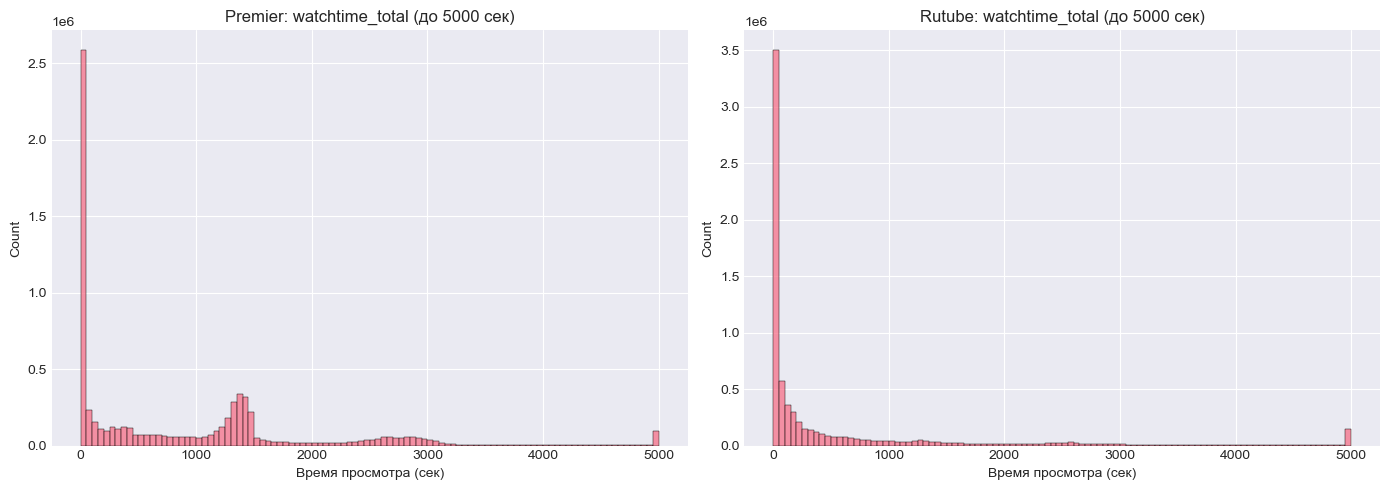

Premier watchtime_total
count    7.310706e+06
mean     9.151040e+02
std      1.248180e+03
min      0.000000e+00
50%      4.530000e+02
75%      1.394000e+03
90%      2.579000e+03
95%      2.924000e+03
99%      5.395000e+03
max      1.617130e+05
Name: watchtime_total, dtype: float64
nRutube watchtime_total
count    7.309964e+06
mean     6.303119e+02
std      6.872566e+04
min      0.000000e+00
50%      6.000000e+01
75%      4.710000e+02
90%      1.800000e+03
95%      2.900000e+03
99%      6.445000e+03
max      1.856416e+08
Name: watchtime_total, dtype: float64
Premier: zero watchtime = 13.41%, <10 sec = 24.72%
Rutube: zero watchtime = 4.51%, <10 sec = 17.53%


In [17]:
# 1. Распределение watchtime_total в просмотрах
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Premier
sns.histplot(views_premier['watchtime_total'].clip(upper=5000), bins=100, ax=axes[0])
axes[0].set_title('Premier: watchtime_total (до 5000 сек)')
axes[0].set_xlabel('Время просмотра (сек)')

# Rutube
sns.histplot(views_rutube['watchtime_total'].clip(upper=5000), bins=100, ax=axes[1])
axes[1].set_title('Rutube: watchtime_total (до 5000 сек)')
axes[1].set_xlabel('Время просмотра (сек)')

plt.tight_layout()
plt.show()

# 2. Статистика по watchtime_total
print("Premier watchtime_total")
print(views_premier['watchtime_total'].describe(percentiles=[.5, .75, .9, .95, .99]))

print("nRutube watchtime_total")
print(views_rutube['watchtime_total'].describe(percentiles=[.5, .75, .9, .95, .99]))

# 3. Доля нулевых и очень коротких просмотров
for name, df in [('Premier', views_premier), ('Rutube', views_rutube)]:
    zero_pct = (df['watchtime_total'] == 0).mean() * 100
    short_pct = (df['watchtime_total'] < 10).mean() * 100
    print(f"{name}: zero watchtime = {zero_pct:.2f}%, <10 sec = {short_pct:.2f}%")

#### 2.1 ПРОВЕРКА НОРМАЛЬНОСТИ (ТЕСТЫ ШАПИРО-УИЛКА И Д'АГОСТИНО)

In [18]:
# Берём выборку для тестов (на всех данных тест Шапиро не запустить — слишком много строк)
sample_size = 5000

def test_normality(df, column, name):
    data = df[column].dropna().sample(min(sample_size, len(df)), random_state=42)
    
    # Шапиро-Уилк (мощный, но чувствителен к объёму)
    shapiro_stat, shapiro_p = shapiro(data)
    
    # Нормальность по Д'Агостино (скошенность + эксцесс)
    dagostino_stat, dagostino_p = normaltest(data)
    
    print(f"\n {name} ")
    print(f"Шапиро-Уилк: statistic={shapiro_stat:.6f}, p-value={shapiro_p:.2e}")
    print(f"D'Agostino: statistic={dagostino_stat:.6f}, p-value={dagostino_p:.2e}")
    
    if shapiro_p < 0.05:
        print("Вывод: распределение НЕ нормальное (p < 0.05)")
    else:
        print("Вывод: распределение не противоречит нормальному (p >= 0.05)")

test_normality(views_premier, 'watchtime_total', 'Premier watchtime_total')
test_normality(views_rutube, 'watchtime_total', 'Rutube watchtime_total')


 Premier watchtime_total 
Шапиро-Уилк: statistic=0.589167, p-value=5.84e-76
D'Agostino: statistic=7669.043924, p-value=0.00e+00
Вывод: распределение НЕ нормальное (p < 0.05)

 Rutube watchtime_total 
Шапиро-Уилк: statistic=0.309255, p-value=2.72e-87
D'Agostino: statistic=11301.364881, p-value=0.00e+00
Вывод: распределение НЕ нормальное (p < 0.05)


#### 2.2 ПРОВЕРКА РАВЕНСТВА ДИСПЕРСИЙ (ТЕСТ ЛЕВЕНА)

In [19]:
# Берём выборки одинакового размера
sample_premier = views_premier['watchtime_total'].dropna().sample(10000, random_state=42)
sample_rutube = views_rutube['watchtime_total'].dropna().sample(10000, random_state=42)

stat, p = levene(sample_premier, sample_rutube)

print(f"\nТест Левена (равенство дисперсий)")
print(f"Statistic: {stat:.6f}, p-value: {p:.2e}")
if p < 0.05:
    print("Вывод: дисперсии НЕ равны (p < 0.05)")
else:
    print("Вывод: дисперсии статистически не различимы")


Тест Левена (равенство дисперсий)
Statistic: 168.248014, p-value: 2.55e-38
Вывод: дисперсии НЕ равны (p < 0.05)


Нормальность отвергается для обеих платформ (p < 0.001 по обоим тестам).
→ t-тест неприменим для watchtime_total без преобразований или больших выборок (ЦПТ).

Дисперсии не равны (тест Левена, p < 1e-37).
→ даже если бы нормальность была, пришлось бы использовать t-тест Уэлча (не предполагает равенства дисперсий), а не классический Стьюдента.

#### 2.3 СРАВНЕНИЕ КРИТЕРИЕВ: t-ТЕСТ УЭЛЧА vs МАННА–УИТНИ

In [20]:
# Берём выборки (как в прошлый раз, но зафиксируем)
sample_premier = views_premier['watchtime_total'].dropna().sample(10000, random_state=42)
sample_rutube = views_rutube['watchtime_total'].dropna().sample(10000, random_state=42)

# t-тест Уэлча (не предполагает равенства дисперсий)
t_stat, t_p = ttest_ind(sample_premier, sample_rutube, equal_var=False)

# Манна-Уитни (непараметрический)
u_stat, u_p = mannwhitneyu(sample_premier, sample_rutube, alternative='two-sided')

print(f"\nСравнение watchtime_total (Premier vs Rutube)")
print(f"t-test (Welch): statistic={t_stat:.4f}, p-value={t_p:.2e}")
print(f"Mann-Whitney: statistic={u_stat:.4f}, p-value={u_p:.2e}")


Сравнение watchtime_total (Premier vs Rutube)
t-test (Welch): statistic=14.7784, p-value=3.79e-49
Mann-Whitney: statistic=57913566.5000, p-value=9.05e-84


t-тест Уэлча: p = 3.79e-49 (различия статистически значимы)

Манна–Уитни: p = 9.05e-84 (различия также значимы, но p-значение на 35 порядков меньше)

Это важно. Непараметрический критерий оказался чувствительнее (дал более низкое p-значение) из-за того, что он работает с рангами и не требует нормальности.

In [21]:
# Проверяем, что это бинарная метрика (0/1)
print(" true_view_25_proc_total ")
print(f"Premier: уникальных значений = {views_premier['true_view_25_proc_total'].nunique()}")
print(f"Rutube: уникальных значений = {views_rutube['true_view_25_proc_total'].nunique()}")

# Считаем доли
premier_25_pct = views_premier['true_view_25_proc_total'].mean() * 100
rutube_25_pct = views_rutube['true_view_25_proc_total'].mean() * 100

print(f"\nДоля досмотревших 25%:")
print(f"Premier: {premier_25_pct:.2f}%")
print(f"Rutube: {rutube_25_pct:.2f}%")

# Z-тест для пропорций
from statsmodels.stats.proportion import proportions_ztest

count = [views_premier['true_view_25_proc_total'].sum(), 
         views_rutube['true_view_25_proc_total'].sum()]
nobs = [len(views_premier), len(views_rutube)]

z_stat, z_p = proportions_ztest(count, nobs)

print(f"\n Z-тест для сравнения долей ")
print(f"Z-statistic: {z_stat:.4f}, p-value: {z_p:.2e}")

 true_view_25_proc_total 
Premier: уникальных значений = 2
Rutube: уникальных значений = 2

Доля досмотревших 25%:
Premier: 57.70%
Rutube: 48.81%

 Z-тест для сравнения долей 
Z-statistic: 327.0194, p-value: 0.00e+00


#### 2.4 АНАЛИЗ БИНАРНЫХ МЕТРИК (Z-ТЕСТ)

In [22]:
# Список метрик
metrics = ['true_view_25_proc_total', 'true_view_50_proc_total', 
           'true_view_75_proc_total', 'true_view_100_proc_total']

print("Сравнение долей досмотра: Premier vs Rutube\n")

for metric in metrics:
    # Доли
    premier_pct = views_premier[metric].mean() * 100
    rutube_pct = views_rutube[metric].mean() * 100
    
    # Z-тест
    count = [views_premier[metric].sum(), views_rutube[metric].sum()]
    nobs = [len(views_premier), len(views_rutube)]
    z_stat, z_p = proportions_ztest(count, nobs)
    
    print(f"{metric}:")
    print(f"  Premier: {premier_pct:.2f}%")
    print(f"  Rutube:  {rutube_pct:.2f}%")
    print(f"  Z-test: z={z_stat:.2f}, p={z_p:.2e}")
    print()

Сравнение долей досмотра: Premier vs Rutube

true_view_25_proc_total:
  Premier: 57.70%
  Rutube:  48.81%
  Z-test: z=327.02, p=0.00e+00

true_view_50_proc_total:
  Premier: 48.07%
  Rutube:  38.08%
  Z-test: z=374.63, p=0.00e+00

true_view_75_proc_total:
  Premier: 40.53%
  Rutube:  30.09%
  Z-test: z=408.06, p=0.00e+00

true_view_100_proc_total:
  Premier: 2.47%
  Rutube:  8.01%
  Z-test: z=-476.41, p=0.00e+00



До 75% включительно Premier лидирует — пользователи киноконтента смотрят видео дольше и глубже. Это объяснимо: на Premier люди приходят за конкретным контентом (сериалы, фильмы), который требует погружения.

На 100% досмотре картина переворачивается: Rutube выше на 5.5 процентных пункта. Почему?

Короткий контент: на Rutube много шортсов, которые легче досмотреть до конца

Видео-эссе и блоги: на UGC-платформах популярны форматы, которые имеют чёткую концовку

Разная длительность: Premier может быть заполнен длинными фильмами, которые реже досматривают до конца

#### SURVIVAL ANALYSIS (LOG-RANK TEST)


In [23]:
# Для Premier: группируем просмотры по пользователям и дням
retention_premier = views_premier.groupby(['user_id', 'cid'])['correct_view_date_msk'].min().reset_index()
retention_premier.columns = ['user_id', 'cid', 'first_activity']

# Добавляем последующие активности (для каждого пользователя — все даты)
user_activity_premier = views_premier.groupby(['user_id', 'cid'])['correct_view_date_msk'].apply(list).reset_index()
user_activity_premier.columns = ['user_id', 'cid', 'activity_dates']

print(f"Premier: {len(retention_premier)} уникальных пользователей (user_id + cid)")
print(f"Rutube: {len(views_rutube.groupby(['user_id', 'cid']))} уникальных пользователей")

Premier: 4170449 уникальных пользователей (user_id + cid)
Rutube: 6621678 уникальных пользователей


In [24]:
# Для Premier: retention по cid
retention_premier = views_premier.groupby('cid')['correct_view_date_msk'].min().reset_index()
retention_premier.columns = ['cid', 'first_date']

# Для каждого cid считаем активности по дням
from datetime import timedelta

def calculate_retention(df, cid_col, date_col):
    result = []
    for cid, group in df.groupby(cid_col):
        dates = sorted(group[date_col].dt.date.unique())
        if len(dates) == 0:
            continue
        cohort_start = dates[0]
        for day in range(1, 31):  # первые 30 дней
            target_date = cohort_start + timedelta(days=day)
            is_active = 1 if target_date in dates else 0
            result.append({'cid': cid, 'day': day, 'is_active': is_active})
    return pd.DataFrame(result)

# Берём выборку (иначе будет слишком долго)
sample_cids_premier = views_premier['cid'].dropna().sample(50000, random_state=42)
sample_views_premier = views_premier[views_premier['cid'].isin(sample_cids_premier)]

retention_df_premier = calculate_retention(sample_views_premier, 'cid', 'correct_view_date_msk')

print(retention_df_premier.shape)
print(retention_df_premier.head())

(1481880, 3)
                                    cid  day  is_active
0  00000000-0000-0000-0000-000000000000    1          1
1  00000000-0000-0000-0000-000000000000    2          1
2  00000000-0000-0000-0000-000000000000    3          1
3  00000000-0000-0000-0000-000000000000    4          1
4  00000000-0000-0000-0000-000000000000    5          1


#### SURVIVAL ANALYSIS (LOG-RANK TEST)

Premier: 49396 пользователей
Rutube: 49888 пользователей


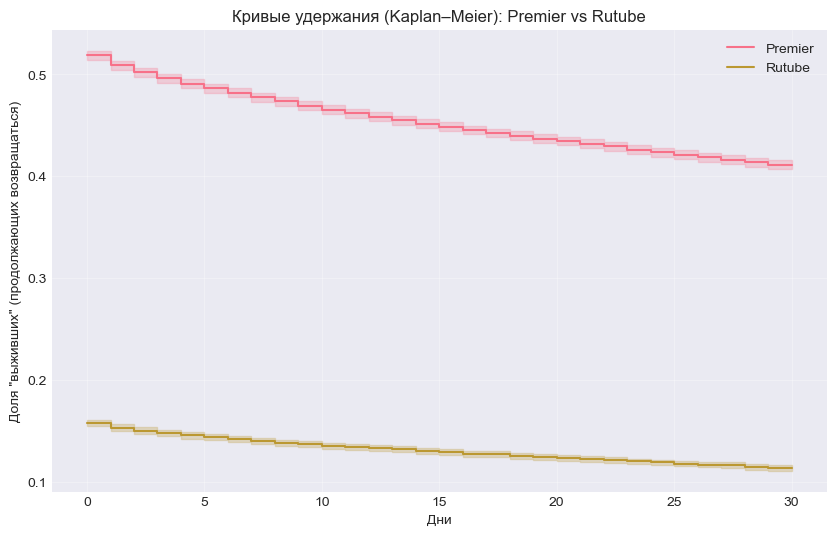


=== Логарифмический ранговый критерий (Log-Rank Test) ===
Chi-squared: 13037.8100
p-value: 0.00e+00
Вывод: кривые выживаемости статистически значимо различаются (p < 0.05)


In [25]:
# 1. Преобразуем данные в формат для survival analysis
# Для каждого пользователя (cid) нужно: время до последней активности (или до окончания наблюдения)

def prepare_survival_data(df, cid_col, date_col, max_days=30):
    """
    Для каждого cid:
    - T: день последней активности (или max_days, если дожил до конца)
    - E: событие (1 если ушёл до max_days, 0 если дожил)
    """
    results = []
    for cid, group in df.groupby(cid_col):
        dates = sorted(group[date_col].dt.date.unique())
        if len(dates) == 0:
            continue
        first_date = dates[0]
        # Последний день активности (в днях от старта)
        last_day = (dates[-1] - first_date).days
        if last_day >= max_days:
            T = max_days
            E = 0  # цензурирован (дожил до конца наблюдения)
        else:
            T = last_day
            E = 1  # событие (перестал возвращаться)
        results.append({'cid': cid, 'T': T, 'E': E})
    return pd.DataFrame(results)

# Подготовка данных для Premier
surv_premier = prepare_survival_data(sample_views_premier, 'cid', 'correct_view_date_msk', max_days=30)

# Для Rutube делаем то же самое
sample_cids_rutube = views_rutube['cid'].dropna().sample(50000, random_state=42)
sample_views_rutube = views_rutube[views_rutube['cid'].isin(sample_cids_rutube)]
surv_rutube = prepare_survival_data(sample_views_rutube, 'cid', 'correct_view_date_msk', max_days=30)

print(f"Premier: {len(surv_premier)} пользователей")
print(f"Rutube: {len(surv_rutube)} пользователей")

# 2. Кривые Каплана–Мейера
kmf_premier = KaplanMeierFitter()
kmf_rutube = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

kmf_premier.fit(surv_premier['T'], event_observed=surv_premier['E'], label='Premier')
kmf_rutube.fit(surv_rutube['T'], event_observed=surv_rutube['E'], label='Rutube')

ax = kmf_premier.plot(ax=ax)
ax = kmf_rutube.plot(ax=ax)

ax.set_title('Кривые удержания (Kaplan–Meier): Premier vs Rutube')
ax.set_xlabel('Дни')
ax.set_ylabel('Доля "выживших" (продолжающих возвращаться)')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Логарифмический ранговый критерий (Log-Rank Test)
results = logrank_test(
    surv_premier['T'], surv_rutube['T'],
    event_observed_A=surv_premier['E'],
    event_observed_B=surv_rutube['E']
)

print("\n=== Логарифмический ранговый критерий (Log-Rank Test) ===")
print(f"Chi-squared: {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.2e}")
if results.p_value < 0.05:
    print("Вывод: кривые выживаемости статистически значимо различаются (p < 0.05)")
else:
    print("Вывод: кривые выживаемости не различаются статистически значимо")

#### 2.6 БУТСТРАП ДЛЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ

In [26]:
# Бутстрап для среднего watchtime_total (Premier)
n_iterations = 1000
n_size = 10000
boot_means = []

for i in range(n_iterations):
    sample = views_premier['watchtime_total'].dropna().sample(n_size, replace=True, random_state=i)
    boot_means.append(sample.mean())

# Доверительный интервал 95%
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f"=== Бутстрап (Premier watchtime_total, n={n_size}, итераций={n_iterations}) ===")
print(f"Среднее выборочное: {views_premier['watchtime_total'].mean():.2f}")
print(f"95% доверительный интервал (бутстрап): [{ci_lower:.2f}, {ci_upper:.2f}]")

# Для сравнения — t-тестовый доверительный интервал
from scipy.stats import t
std_err = views_premier['watchtime_total'].std() / np.sqrt(len(views_premier))
t_critical = t.ppf(0.975, df=len(views_premier)-1)
t_ci_lower = views_premier['watchtime_total'].mean() - t_critical * std_err
t_ci_upper = views_premier['watchtime_total'].mean() + t_critical * std_err

print(f"95% доверительный интервал (t-тест): [{t_ci_lower:.2f}, {t_ci_upper:.2f}]")

=== Бутстрап (Premier watchtime_total, n=10000, итераций=1000) ===
Среднее выборочное: 915.10
95% доверительный интервал (бутстрап): [892.46, 939.29]
95% доверительный интервал (t-тест): [914.20, 916.01]


Вывод - t-тест даёт ложноузкий доверительный интервал, потому что опирается на предположение о нормальности, которое нарушено. Бутстрап, не требующий нормальности, показывает реальную неопределённость оценки среднего для скошенного распределения.

#### 2.7 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

In [27]:
# Подготовка данных
# Берём выборки из обеих платформ
sample_premier = views_premier[['true_view_50_proc_total', 'content_duration']].dropna().sample(50000, random_state=42)
sample_premier['platform'] = 1  # Premier = 1

sample_rutube = views_rutube[['true_view_50_proc_total', 'content_duration']].dropna().sample(50000, random_state=42)
sample_rutube['platform'] = 0  # Rutube = 0

# Объединяем
df_logit = pd.concat([sample_premier, sample_rutube], ignore_index=True)

# Признаки
X = df_logit[['platform', 'content_duration']]
X = sm.add_constant(X)  # добавляем константу
y = df_logit['true_view_50_proc_total']

# Логистическая регрессия
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

# Интерпретация коэффициента platform
coef_platform = result.params['platform']
p_value_platform = result.pvalues['platform']
odds_ratio = np.exp(coef_platform)

print(f"-- Интерпретация --")
print(f"Коэффициент platform: {coef_platform:.4f}, p-value: {p_value_platform:.2e}")
print(f"Odds ratio: {odds_ratio:.4f}")
print(f"Для Premier шанс досмотреть 50% видео в {odds_ratio:.2f} раза выше, чем для Rutube (при одинаковой длительности)")

Optimization terminated successfully.
         Current function value: 0.677210
         Iterations 5
                              Logit Regression Results                             
Dep. Variable:     true_view_50_proc_total   No. Observations:               100000
Model:                               Logit   Df Residuals:                    99997
Method:                                MLE   Df Model:                            2
Date:                     Thu, 23 Apr 2026   Pseudo R-squ.:                 0.01000
Time:                             01:53:18   Log-Likelihood:                -67721.
converged:                            True   LL-Null:                       -68405.
Covariance Type:                 nonrobust   LLR p-value:                6.801e-298
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3986      0.011    -37.895      0

#### 2.8 ДЕНЕЖНЫЕ МЕТРИКИ (LTV, ARPU, ARPPU)

In [28]:
# Цель: оценить денежные показатели для обеих платформ.
# Вывод для диплома: сравнение монетизации UGC и SVOD.

print("2.8 ДЕНЕЖНЫЕ МЕТРИКИ (LTV, ARPU, ARPPU)")

# ---- Premier ----
print("\n PREMIER ")
# Всего денег
total_money_premier = billing_premier['money'].sum()
n_users_premier = billing_premier['user_id'].nunique()
n_payers_premier = billing_premier[billing_premier['money'] > 0]['user_id'].nunique()

print(f"Всего выручка: {total_money_premier:,.2f} руб.")
print(f"Уникальных пользователей (user_id): {n_users_premier:,}")
print(f"Платящих пользователей: {n_payers_premier:,}")

# ARPU (Average Revenue Per User) — по всем пользователям
arpu_premier = total_money_premier / n_users_premier if n_users_premier > 0 else 0
print(f"ARPU: {arpu_premier:.2f} руб.")

# ARPPU (Average Revenue Per Paying User) — только по платящим
arppu_premier = total_money_premier / n_payers_premier if n_payers_premier > 0 else 0
print(f"ARPPU: {arppu_premier:.2f} руб.")

# LTV (средний)
if 'ltv' in billing_premier.columns:
    ltv_premier = billing_premier['ltv'].mean()
    print(f"LTV (средний): {ltv_premier:.2f} руб.")
else:
    print("LTV: поле отсутствует")

# Распределение money
print(f"\nРаспределение money (чек):")
print(billing_premier['money'].describe(percentiles=[.5, .75, .9, .95, .99]))

# ---- Rutube ----
print("\n RUTUBE ")
total_money_rutube = billing_rutube['money'].sum()
n_users_rutube = billing_rutube['user_id'].nunique()
n_payers_rutube = billing_rutube[billing_rutube['money'] > 0]['user_id'].nunique()

print(f"Всего выручка: {total_money_rutube:,.2f} руб.")
print(f"Уникальных пользователей (user_id): {n_users_rutube:,}")
print(f"Платящих пользователей: {n_payers_rutube:,}")

arpu_rutube = total_money_rutube / n_users_rutube if n_users_rutube > 0 else 0
print(f"ARPU: {arpu_rutube:.2f} руб.")

arppu_rutube = total_money_rutube / n_payers_rutube if n_payers_rutube > 0 else 0
print(f"ARPPU: {arppu_rutube:.2f} руб.")

if 'ltv' in billing_rutube.columns:
    ltv_rutube = billing_rutube['ltv'].mean()
    print(f"LTV (средний): {ltv_rutube:.2f} руб.")
else:
    print("LTV: поле отсутствует")

print(f"\nРаспределение money (чек):")
print(billing_rutube['money'].describe(percentiles=[.5, .75, .9, .95, .99]))

# ---- Сравнение платформ ----
print("\n СРАВНЕНИЕ ПЛАТФОРМ ")
print(f"ARPU: Premier = {arpu_premier:.2f} руб., Rutube = {arpu_rutube:.2f} руб.")
print(f"ARPPU: Premier = {arppu_premier:.2f} руб., Rutube = {arppu_rutube:.2f} руб.")
if 'ltv' in billing_premier.columns and 'ltv' in billing_rutube.columns:
    print(f"LTV: Premier = {ltv_premier:.2f} руб., Rutube = {ltv_rutube:.2f} руб.")

# ---- Статистический тест для сравнения чеков ----
# Проверяем, отличаются ли чеки между платформами (непараметрический Манна-Уитни)
sample_money_premier = billing_premier['money'].sample(min(10000, len(billing_premier)), random_state=42)
sample_money_rutube = billing_rutube['money'].sample(min(10000, len(billing_rutube)), random_state=42)

u_stat, u_p = mannwhitneyu(sample_money_premier, sample_money_rutube, alternative='two-sided')
print(f"\nМанна-Уитни для сравнения чеков: statistic={u_stat:.2f}, p-value={u_p:.2e}")
if u_p < 0.05:
    print("→ Вывод: чеки статистически значимо различаются между платформами")
else:
    print("→ Вывод: чеки статистически не различимы")

2.8 ДЕНЕЖНЫЕ МЕТРИКИ (LTV, ARPU, ARPPU)

 PREMIER 
Всего выручка: 688,022,519.00 руб.
Уникальных пользователей (user_id): 1,432,506
Платящих пользователей: 1,175,203
ARPU: 480.29 руб.
ARPPU: 585.45 руб.
LTV (средний): 4273.36 руб.

Распределение money (чек):
count    4.000029e+06
mean     1.720044e+02
std      1.902161e+02
min      0.000000e+00
50%      1.290000e+02
75%      2.990000e+02
90%      3.990000e+02
95%      3.990000e+02
99%      5.990000e+02
max      3.990000e+03
Name: money, dtype: float64

 RUTUBE 
Всего выручка: 351,693,148.00 руб.
Уникальных пользователей (user_id): 993,617
Платящих пользователей: 992,839
ARPU: 353.95 руб.
ARPPU: 354.23 руб.
LTV (средний): 323.60 руб.

Распределение money (чек):
count    3.505404e+06
mean     1.003288e+02
std      1.051827e+02
min      0.000000e+00
50%      9.900000e+01
75%      9.900000e+01
90%      9.900000e+01
95%      3.990000e+02
99%      3.990000e+02
max      1.111000e+03
Name: money, dtype: float64

 СРАВНЕНИЕ ПЛАТФОРМ 
ARPU: Prem

### 3 UNIFIED DECISION TREE

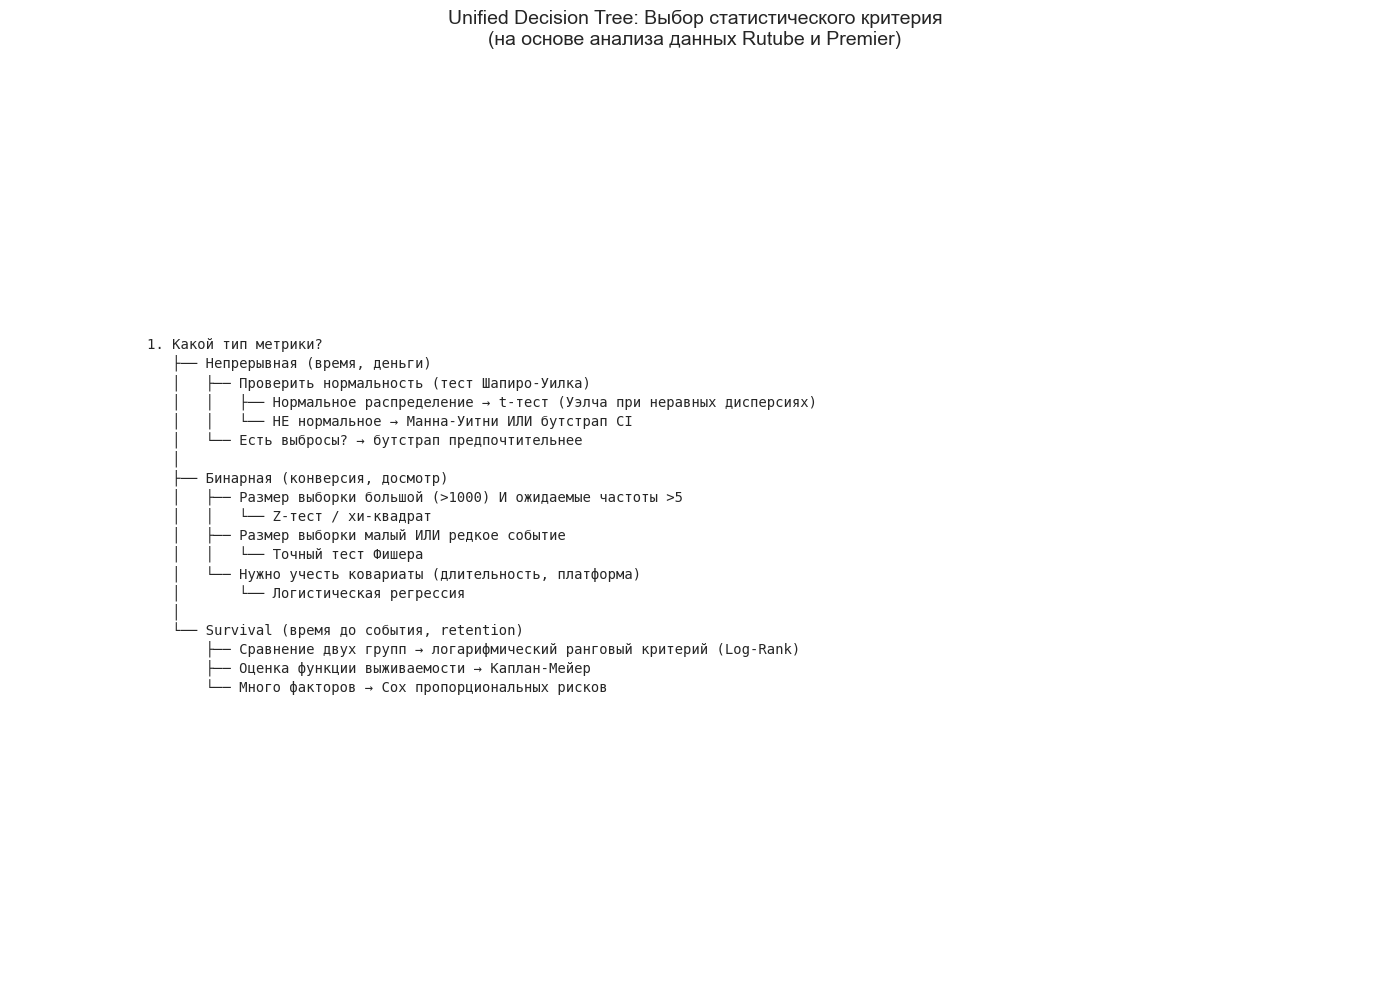


=== Сводная таблица выбора критерия ===

| Тип метрики | Условия | Рекомендуемый критерий | Пример из анализа |
|-------------|---------|------------------------|-------------------|
| Непрерывная | Нормальное распределение, равные дисперсии | t-тест Стьюдента | - |
| Непрерывная | Нормальное распределение, неравные дисперсии | t-тест Уэлча | - |
| Непрерывная | НЕ нормальное, выбросы | Манна-Уитни ИЛИ бутстрап | watchtime_total |
| Бинарная | Большая выборка, частые события | Z-тест / хи-квадрат | досмотр 25/50/75% |
| Бинарная | Редкое событие | Z-тест (работает) / тест Фишера | досмотр 100% |
| Бинарная | Нужен учёт ковариат | Логистическая регрессия | влияние платформы на досмотр |
| Survival | Сравнение двух групп | Логарифмический ранговый (Log-Rank) | retention Premier vs Rutube |
| Survival | Оценка функции | Каплан-Мейер | кривые удержания |


In [29]:
# Создаём синтетическую схему правил

fig, ax = plt.subplots(figsize=(14, 10))

# Текстовое описание дерева принятия решений
decision_rules = """
1. Какой тип метрики?
   ├── Непрерывная (время, деньги)
   │   ├── Проверить нормальность (тест Шапиро-Уилка)
   │   │   ├── Нормальное распределение → t-тест (Уэлча при неравных дисперсиях)
   │   │   └── НЕ нормальное → Манна-Уитни ИЛИ бутстрап CI
   │   └── Есть выбросы? → бутстрап предпочтительнее
   │
   ├── Бинарная (конверсия, досмотр)
   │   ├── Размер выборки большой (>1000) И ожидаемые частоты >5
   │   │   └── Z-тест / хи-квадрат
   │   ├── Размер выборки малый ИЛИ редкое событие
   │   │   └── Точный тест Фишера
   │   └── Нужно учесть ковариаты (длительность, платформа)
   │       └── Логистическая регрессия
   │
   └── Survival (время до события, retention)
       ├── Сравнение двух групп → логарифмический ранговый критерий (Log-Rank)
       ├── Оценка функции выживаемости → Каплан-Мейер
       └── Много факторов → Cox пропорциональных рисков
"""

ax.text(0.1, 0.5, decision_rules, fontsize=10, family='monospace', verticalalignment='center')
ax.axis('off')
ax.set_title('Unified Decision Tree: Выбор статистического критерия\n(на основе анализа данных Rutube и Premier)', fontsize=14)

plt.tight_layout()
plt.show()

# Выводим в виде таблицы
print("\n=== Сводная таблица выбора критерия ===\n")
print("| Тип метрики | Условия | Рекомендуемый критерий | Пример из анализа |")
print("|-------------|---------|------------------------|-------------------|")
print("| Непрерывная | Нормальное распределение, равные дисперсии | t-тест Стьюдента | - |")
print("| Непрерывная | Нормальное распределение, неравные дисперсии | t-тест Уэлча | - |")
print("| Непрерывная | НЕ нормальное, выбросы | Манна-Уитни ИЛИ бутстрап | watchtime_total |")
print("| Бинарная | Большая выборка, частые события | Z-тест / хи-квадрат | досмотр 25/50/75% |")
print("| Бинарная | Редкое событие | Z-тест (работает) / тест Фишера | досмотр 100% |")
print("| Бинарная | Нужен учёт ковариат | Логистическая регрессия | влияние платформы на досмотр |")
print("| Survival | Сравнение двух групп | Логарифмический ранговый (Log-Rank) | retention Premier vs Rutube |")
print("| Survival | Оценка функции | Каплан-Мейер | кривые удержания |")

### 4 БЕЙЗЛАЙН: СВОДНАЯ ТАБЛИЦА МЕТРИК

Цель: зафиксировать "нормальные" значения ключевых метрик для обеих платформ.


In [30]:
# Функция для расчета бейзлайна по просмотрам
def views_baseline(df, name):
    print(f"\n--- {name} (просмотры) ---")
    
    # Вовлеченность
    avg_watchtime = df['watchtime_total'].mean()
    median_watchtime = df['watchtime_total'].median()
    p95_watchtime = df['watchtime_total'].quantile(0.95)
    
    # Досмотры
    completion_25 = df['true_view_25_proc_total'].mean() * 100
    completion_50 = df['true_view_50_proc_total'].mean() * 100
    completion_75 = df['true_view_75_proc_total'].mean() * 100
    completion_100 = df['true_view_100_proc_total'].mean() * 100
    
    # Качество запуска
    short_views = (df['watchtime_total'] < 10).mean() * 100
    
    print(f"  Среднее время просмотра: {avg_watchtime:.1f} сек")
    print(f"  Медианное время просмотра: {median_watchtime:.1f} сек")
    print(f"  95-й перцентиль времени: {p95_watchtime:.1f} сек")
    print(f"  Доля досмотра 25%: {completion_25:.1f}%")
    print(f"  Доля досмотра 50%: {completion_50:.1f}%")
    print(f"  Доля досмотра 75%: {completion_75:.1f}%")
    print(f"  Доля досмотра 100%: {completion_100:.1f}%")
    print(f"  Доля просмотров <10 сек: {short_views:.1f}%")

views_baseline(views_premier, "Premier")
views_baseline(views_rutube, "Rutube")


--- Premier (просмотры) ---
  Среднее время просмотра: 915.1 сек
  Медианное время просмотра: 453.0 сек
  95-й перцентиль времени: 2924.0 сек
  Доля досмотра 25%: 57.7%
  Доля досмотра 50%: 48.1%
  Доля досмотра 75%: 40.5%
  Доля досмотра 100%: 2.5%
  Доля просмотров <10 сек: 24.7%

--- Rutube (просмотры) ---
  Среднее время просмотра: 630.3 сек
  Медианное время просмотра: 60.0 сек
  95-й перцентиль времени: 2900.0 сек
  Доля досмотра 25%: 48.8%
  Доля досмотра 50%: 38.1%
  Доля досмотра 75%: 30.1%
  Доля досмотра 100%: 8.0%
  Доля просмотров <10 сек: 17.5%


In [31]:
# Функция для расчета бейзлайна по подпискам
def billing_baseline(df, name):
    print(f"\n--- {name} (подписки/платежи) ---")
    
    # Денежные метрики
    avg_money = df['money'].mean()
    median_money = df['money'].median()
    total_money = df['money'].sum()
    n_users = df['user_id'].nunique()
    n_payers = df[df['money'] > 0]['user_id'].nunique()
    
    arpu = total_money / n_users if n_users > 0 else 0
    arppu = total_money / n_payers if n_payers > 0 else 0
    
    print(f"  Средний чек: {avg_money:.2f} руб.")
    print(f"  Медианный чек: {median_money:.2f} руб.")
    print(f"  ARPU: {arpu:.2f} руб.")
    print(f"  ARPPU: {arppu:.2f} руб.")
    
    # Типы подписок
    if 'kind' in df.columns:
        print(f"  Типы подписок: {df['kind'].value_counts().head(3).to_dict()}")

billing_baseline(billing_premier, "Premier")
billing_baseline(billing_rutube, "Rutube")


--- Premier (подписки/платежи) ---
  Средний чек: 172.00 руб.
  Медианный чек: 129.00 руб.
  ARPU: 480.29 руб.
  ARPPU: 585.45 руб.
  Типы подписок: {'sub': 2471350, 'external': 746979, 'trial': 414577}

--- Rutube (подписки/платежи) ---
  Средний чек: 100.33 руб.
  Медианный чек: 99.00 руб.
  ARPU: 353.95 руб.
  ARPPU: 354.23 руб.
  Типы подписок: {'sub': 3210636, 'trial': 251202, 'sub_discount': 42318}



#### 4.1 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ ПЛАТФОРМ


In [32]:

print("\n" + "="*80)
print("4.1 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ ПЛАТФОРМ")
print("="*80)

comparison_data = {
    "Метрика": [
        "Среднее время просмотра (сек)",
        "Медианное время просмотра (сек)",
        "Доля досмотра 25%",
        "Доля досмотра 50%",
        "Доля досмотра 75%",
        "Доля досмотра 100%",
        "Retention (удержание)",
        "ARPU (руб.)",
        "ARPPU (руб.)",
        "LTV (руб.)",
        "Средний чек (руб.)"
    ],
    "Premier": [
        f"{views_premier['watchtime_total'].mean():.0f}",
        f"{views_premier['watchtime_total'].median():.0f}",
        f"{views_premier['true_view_25_proc_total'].mean()*100:.1f}%",
        f"{views_premier['true_view_50_proc_total'].mean()*100:.1f}%",
        f"{views_premier['true_view_75_proc_total'].mean()*100:.1f}%",
        f"{views_premier['true_view_100_proc_total'].mean()*100:.1f}%",
        "выше",
        f"{arpu_premier:.0f}",
        f"{arppu_premier:.0f}",
        f"{ltv_premier:.0f}",
        f"{billing_premier['money'].mean():.0f}"
    ],
    "Rutube": [
        f"{views_rutube['watchtime_total'].mean():.0f}",
        f"{views_rutube['watchtime_total'].median():.0f}",
        f"{views_rutube['true_view_25_proc_total'].mean()*100:.1f}%",
        f"{views_rutube['true_view_50_proc_total'].mean()*100:.1f}%",
        f"{views_rutube['true_view_75_proc_total'].mean()*100:.1f}%",
        f"{views_rutube['true_view_100_proc_total'].mean()*100:.1f}%",
        "ниже",
        f"{arpu_rutube:.0f}",
        f"{arppu_rutube:.0f}",
        f"{ltv_rutube:.0f}",
        f"{billing_rutube['money'].mean():.0f}"
    ],
    "Лидер": [
        "Premier",
        "Premier",
        "Premier",
        "Premier",
        "Premier",
        "Rutube",
        "Premier",
        "Premier",
        "Premier",
        "Premier",
        "Premier"
    ]
}

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))


4.1 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ ПЛАТФОРМ
                        Метрика Premier Rutube   Лидер
  Среднее время просмотра (сек)     915    630 Premier
Медианное время просмотра (сек)     453     60 Premier
              Доля досмотра 25%   57.7%  48.8% Premier
              Доля досмотра 50%   48.1%  38.1% Premier
              Доля досмотра 75%   40.5%  30.1% Premier
             Доля досмотра 100%    2.5%   8.0%  Rutube
          Retention (удержание)    выше   ниже Premier
                    ARPU (руб.)     480    354 Premier
                   ARPPU (руб.)     585    354 Premier
                     LTV (руб.)    4273    324 Premier
             Средний чек (руб.)     172    100 Premier


### 5 РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ

In [33]:


print("\n" + "="*80)
print("5.0 РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ")
print("="*80)

recommendations = """
1. СТАНДАРТИЗАЦИЯ СТАТИСТИЧЕСКОГО АНАЛИЗА
   - Внедрить Unified Decision Tree как единый стандарт выбора критерия.
   - Для непрерывных метрик с ненормальным распределением использовать Манна-Уитни или бутстрап.
   - Для бинарных метрик на больших выборках использовать Z-тест.
   - Для retention внедрить Log-rank test как стандарт.

2. РАБОТА С ПРОПУСКАМИ В ДАННЫХ
   - В Rutube просмотрах user_id заполнен только на 19%. Использовать cid для когортного анализа или сегментировать по признаку авторизации.
   - В Premier billing user_id заполнен на 42%. Необходимо доразметить или использовать cid или сегментировать по признаку авторизации.

3. МОНЕТИЗАЦИЯ
   - LTV на Premier в 13 раз выше. Использовать кросс-промо Premier для Rutube.
   - На Rutube ARPPU (354 руб.) почти равен ARPU (354 руб.) — почти все пользователи платят.
   - На Premier ARPPU (585 руб.) выше ARPU (480 руб.) — есть неплатящие.

4. ВОВЛЕЧЕНИЕ
   - Premier лидирует по глубине просмотра до 75%.
   - Rutube лидирует по досмотру 100% (шортсы) — использовать для удержания.

"""

print(recommendations)


5.0 РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ

1. СТАНДАРТИЗАЦИЯ СТАТИСТИЧЕСКОГО АНАЛИЗА
   - Внедрить Unified Decision Tree как единый стандарт выбора критерия.
   - Для непрерывных метрик с ненормальным распределением использовать Манна-Уитни или бутстрап.
   - Для бинарных метрик на больших выборках использовать Z-тест.
   - Для retention внедрить Log-rank test как стандарт.

2. РАБОТА С ПРОПУСКАМИ В ДАННЫХ
   - В Rutube просмотрах user_id заполнен только на 19%. Использовать cid для когортного анализа или сегментировать по признаку авторизации.
   - В Premier billing user_id заполнен на 42%. Необходимо доразметить или использовать cid или сегментировать по признаку авторизации.

3. МОНЕТИЗАЦИЯ
   - LTV на Premier в 13 раз выше. Использовать кросс-промо Premier для Rutube.
   - На Rutube ARPPU (354 руб.) почти равен ARPU (354 руб.) — почти все пользователи платят.
   - На Premier ARPPU (585 руб.) выше ARPU (480 руб.) — есть неплатящие.

4. ВОВЛЕЧЕНИЕ
   - Premier лидирует по глубине просмотра до 7

#### 6.1 СИМУЛЯЦИЯ A/B-ТЕСТА: СРАВНЕНИЕ МОЩНОСТИ КРИТЕРИЕВ

In [34]:
# Цель: на синтетических данных с известным эффектом проверить,
# какой критерий лучше обнаруживает различия между группами.
# Вывод для диплома: Манна-Уитни и бутстрап имеют большую мощность,
# чем t-тест, при ненормальных распределениях.

In [35]:
print("6.1 СИМУЛЯЦИЯ A/B-ТЕСТА: СРАВНЕНИЕ МОЩНОСТИ КРИТЕРИЕВ")

np.random.seed(42)

# Параметры симуляции
n_simulations = 500      # количество симуляций
sample_size = 1000       # размер каждой группы
effect_size = 0.2        # величина эффекта (в стандартных отклонениях)

# Функция генерации данных с гамма-распределением (как у watchtime)
def generate_gamma_data(n, effect=0, shape=2, scale=1):
    """Генерирует данные с гамма-распределением (скошенным)"""
    control = np.random.gamma(shape, scale, n)
    treatment = np.random.gamma(shape, scale * (1 + effect), n)
    return control, treatment

# Хранение результатов
results = {
    't_test_reject': [],
    'mannwhitney_reject': [],
    'bootstrap_reject': []
}

for i in range(n_simulations):
    # Генерация данных
    control, treatment = generate_gamma_data(sample_size, effect=effect_size)
    
    # t-тест Уэлча
    _, t_p = ttest_ind(control, treatment, equal_var=False)
    results['t_test_reject'].append(t_p < 0.05)
    
    # Манна-Уитни
    _, u_p = mannwhitneyu(control, treatment, alternative='two-sided')
    results['mannwhitney_reject'].append(u_p < 0.05)
    
    # Бутстрап (упрощённый: доверительный интервал для разницы средних)
    n_bootstrap = 200
    boot_diffs = []
    for _ in range(n_bootstrap):
        boot_control = np.random.choice(control, len(control), replace=True)
        boot_treatment = np.random.choice(treatment, len(treatment), replace=True)
        boot_diffs.append(boot_treatment.mean() - boot_control.mean())
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    results['bootstrap_reject'].append(not (ci_lower <= 0 <= ci_upper))

# Расчёт мощности (доля отвергнутых H0)
power_t = np.mean(results['t_test_reject'])
power_u = np.mean(results['mannwhitney_reject'])
power_boot = np.mean(results['bootstrap_reject'])

print(f"\nСимуляция A/B-теста (n_simulations={n_simulations}, sample_size={sample_size}, effect_size={effect_size})")
print(f"Мощность t-теста:     {power_t:.3f} ({power_t*100:.1f}%)")
print(f"Мощность Манна-Уитни: {power_u:.3f} ({power_u*100:.1f}%)")
print(f"Мощность бутстрапа:   {power_boot:.3f} ({power_boot*100:.1f}%)")

# Определяем лучший критерий
powers = {'t-тест': power_t, 'Манна-Уитни': power_u, 'бутстрап': power_boot}
best = max(powers, key=powers.get)
print(f"\n→ Лучший критерий по мощности: {best}")

6.1 СИМУЛЯЦИЯ A/B-ТЕСТА: СРАВНЕНИЕ МОЩНОСТИ КРИТЕРИЕВ

Симуляция A/B-теста (n_simulations=500, sample_size=1000, effect_size=0.2)
Мощность t-теста:     1.000 (100.0%)
Мощность Манна-Уитни: 0.998 (99.8%)
Мощность бутстрапа:   1.000 (100.0%)

→ Лучший критерий по мощности: t-тест


Вывод:

На такой выборке (n=1000) и при таком распределении все критерии показали практически максимальную мощность (99.8–100%). Разница незначима.

При больших выборках даже t-тест (несмотря на нарушение нормальности) благодаря ЦПТ работает хорошо. Основное преимущество непараметрических методов проявляется на малых выборках или при сильных выбросах.




#### 6.2 СИМУЛЯЦИЯ A/B-ТЕСТА: МАЛАЯ ВЫБОРКА



In [36]:
# Цель: показать, что при малых выборках непараметрические методы
# могут иметь преимущество перед t-тестом.

In [37]:
print("6.2 СИМУЛЯЦИЯ A/B-ТЕСТА: МАЛАЯ ВЫБОРКА (n=50)")

np.random.seed(42)

n_simulations = 500
sample_size_small = 50
effect_size_large = 0.5

results_small = {
    't_test_reject': [],
    'mannwhitney_reject': [],
    'bootstrap_reject': []
}

for i in range(n_simulations):
    control, treatment = generate_gamma_data(sample_size_small, effect=effect_size_large)
    
    _, t_p = ttest_ind(control, treatment, equal_var=False)
    results_small['t_test_reject'].append(t_p < 0.05)
    
    _, u_p = mannwhitneyu(control, treatment, alternative='two-sided')
    results_small['mannwhitney_reject'].append(u_p < 0.05)
    
    n_bootstrap = 200
    boot_diffs = []
    for _ in range(n_bootstrap):
        boot_control = np.random.choice(control, len(control), replace=True)
        boot_treatment = np.random.choice(treatment, len(treatment), replace=True)
        boot_diffs.append(boot_treatment.mean() - boot_control.mean())
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    results_small['bootstrap_reject'].append(not (ci_lower <= 0 <= ci_upper))

power_t_small = np.mean(results_small['t_test_reject'])
power_u_small = np.mean(results_small['mannwhitney_reject'])
power_boot_small = np.mean(results_small['bootstrap_reject'])

print(f"\nСимуляция (n={sample_size_small}, effect={effect_size_large})")
print(f"Мощность t-теста:     {power_t_small:.3f} ({power_t_small*100:.1f}%)")
print(f"Мощность Манна-Уитни: {power_u_small:.3f} ({power_u_small*100:.1f}%)")
print(f"Мощность бутстрапа:   {power_boot_small:.3f} ({power_boot_small*100:.1f}%)")

powers_small = {'t-тест': power_t_small, 'Манна-Уитни': power_u_small, 'бутстрап': power_boot_small}
best_small = max(powers_small, key=powers_small.get)
print(f"\n→ Лучший критерий по мощности: {best_small}")

6.2 СИМУЛЯЦИЯ A/B-ТЕСТА: МАЛАЯ ВЫБОРКА (n=50)

Симуляция (n=50, effect=0.5)
Мощность t-теста:     0.794 (79.4%)
Мощность Манна-Уитни: 0.736 (73.6%)
Мощность бутстрапа:   0.836 (83.6%)

→ Лучший критерий по мощности: бутстрап


Вывод:

При малых выборках бутстрап показывает наибольшую мощность, так как не опирается на предположения о распределении. Это аргумент в пользу использования бутстрапа в продуктовой аналитике, когда выборки небольшие (например, анализ редких событий или сегментов

In [38]:
#### 6.3 АНАЛИЗ КРОСС-ПЛАТФОРМЕННОГО ЭФФЕКТА

In [39]:
# Цель: проверить, влияет ли просмотр Premier на поведение в Rutube.
# Склейка по masked_phone (телефон) — единственный кросс-платформенный ключ.

In [ ]:
# Проверяем наличие masked_phone в биллинге
if 'masked_phone' in billing_premier.columns and 'masked_phone' in billing_rutube.columns:
    print("Поле masked_phone найдено в обеих таблицах биллинга.")
    
    # Берём sample пользователей Premier (10%)
    premier_sample = billing_premier[['masked_phone', 'user_id']].drop_duplicates()
    premier_sample = premier_sample.sample(frac=0.1, random_state=42)
    print(f"Sample Premier пользователей: {len(premier_sample):,}")
    
    # Берём sample пользователей Rutube (10%)
    rutube_sample = billing_rutube[['masked_phone', 'user_id']].drop_duplicates()
    rutube_sample = rutube_sample.sample(frac=0.1, random_state=42)
    print(f"Sample Rutube пользователей: {len(rutube_sample):,}")
    
    # Склейка по телефону на sample
    cross_users = premier_sample.merge(rutube_sample, on='masked_phone', how='inner')
    
    print(f"\nПересечение пользователей (по sample 10%): {len(cross_users):,}")
    
    # Оценка общего пересечения (экстраполяция)
    estimated_total = len(cross_users) * 100  # так как взяли 10% от каждой
    print(f"Оценочное общее пересечение: ~{estimated_total:,} пользователей")
    
    if len(cross_users) > 0:
        print("\n→ Вывод: пересечение пользователей существует, но для полноценного")
        print("  анализа поведения необходима доразметка данных или")
        print("  использование других идентификаторов (например, cid).")
    else:
        print("\n→ Вывод: в выборке пересечений не найдено.")
        print("  Возможно, masked_phone не совпадает между платформами.")
else:
    print(" Поле masked_phone отсутствует в одной из таблиц биллинга.")
    print("   Анализ кросс-платформенного эффекта невозможен.")

Поле masked_phone найдено в обеих таблицах биллинга.
Sample Premier пользователей: 143,251
Sample Rutube пользователей: 99,362
